In [3]:
#setup
import os
import re
import urllib.parse
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Configure visual styling globally
sns.set_theme(style='whitegrid')

# REAL FIX: Establish dynamic pathlib anchors matching your workspace
BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_FILE = BASE_DIR / 'dataset' / 'processed' / 'combined_clean.csv'
REPORTS_DIR = BASE_DIR / 'Reports'

# Automatically create the Reports folder if it doesn't exist
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the combined dataset safely
if DATA_FILE.exists():
    df = pd.read_csv(DATA_FILE)
    
    # Map binary target labels to readable text string classifications
    df['class'] = df['label'].map({0: 'Legitimate', 1: 'Phishing'})
    COLORS = {'Legitimate': '#2ecc71', 'Phishing': '#e74c3c'}
    
    print(f"🚀 Success! Dataset loaded cleanly from: {DATA_FILE}")
    print(f"📊 Dataset Matrix Shape: {df.shape}")
    print("-" * 60)
    
    # Display the first 5 rows in the notebook output window
    display(df.head())
else:
    print(f"❌ Error: Target file not found at {DATA_FILE}")
    print("Please run 'python dataset/clean_data.py' first to generate this file.")

🚀 Success! Dataset loaded cleanly from: C:\phishing\phishing-detection-system\dataset\processed\combined_clean.csv
📊 Dataset Matrix Shape: (40000, 3)
------------------------------------------------------------


,url,label,class
0,https://prostovpn.org,0,Legitimate
1,https://xfinityxfin.weebly.com,1,Phishing
2,https://floorsdirectltd.co.uk,0,Legitimate
3,https://communicative-imagine-347682.framer.app,1,Phishing
4,https://rf4-stat.ru,0,Legitimate


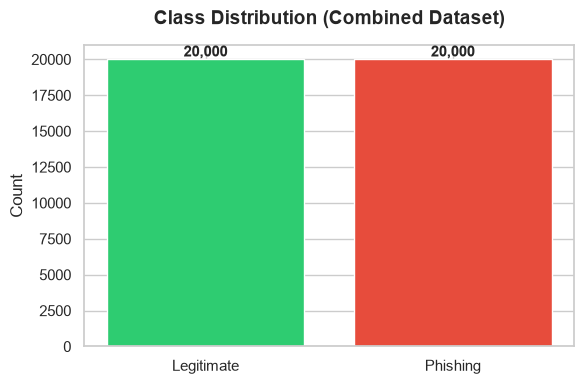

🎉 Distribution chart safely locked away in: C:\phishing\phishing-detection-system\Reports\eda_class_distribution.png


In [4]:
#Class balance chart
# Guard check to verify df is loaded in memory
if 'df' in locals() or 'df' in globals():
    counts = df['class'].value_counts()
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Generate the bars using your pre-defined global COLORS map
    bars = ax.bar(counts.index, counts.values,
                  color=[COLORS[c] for c in counts.index], edgecolor='white')
    
    # Dynamically place text counts above each bar
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 200,
                f"{b.get_height():,}", ha='center', fontsize=11, fontweight='bold')
                
    ax.set_title('Class Distribution (Combined Dataset)', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Count')
    
    # Clean up excess whitespace
    plt.tight_layout()
    
    # REAL FIX: Use your REPORTS_DIR path object instead of lowercase relative string
    save_path = REPORTS_DIR / 'eda_class_distribution.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    print(f"🎉 Distribution chart safely locked away in: {save_path}")
else:
    print("❌ Error: 'df' is not defined. Please run Cell 1 first to load the dataset.")

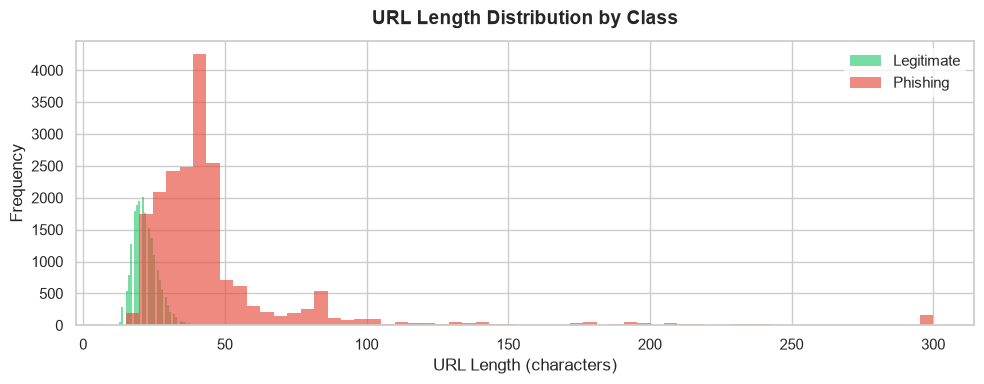

📈 URL Length Statistical Summary:
-----------------------------------------------------------------
              count   mean    std   min   25%   50%   75%     max
class                                                            
Legitimate  20000.0  21.80   4.37  12.0  19.0  21.0  24.0    56.0
Phishing    20000.0  49.42  52.11  15.0  31.0  40.0  46.0  1159.0


In [5]:
#URL length histogram
# Guard check to verify df is loaded in memory
if 'df' in locals() or 'df' in globals():
    # Calculate URL lengths on the fly
    df['url_length'] = df['url'].str.len()
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Overlay histograms for each classification group
    for lbl, grp in df.groupby('class'):
        ax.hist(grp['url_length'].clip(upper=300), bins=60,
                alpha=0.65, label=lbl, color=COLORS[lbl], edgecolor='none')
        
    ax.set_title('URL Length Distribution by Class', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('URL Length (characters)')
    ax.set_ylabel('Frequency')
    ax.legend(frameon=True, facecolor='white', edgecolor='none')
    
    plt.tight_layout()
    
    # REAL FIX: Use your predefined REPORTS_DIR path object
    save_path = REPORTS_DIR / 'eda_url_length.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    # Print the exact descriptive statistics table directly below the plot
    print("📈 URL Length Statistical Summary:")
    print("-" * 65)
    print(df.groupby('class')['url_length'].describe().round(2))
else:
    print("❌ Error: 'df' is not defined. Please run Cell 1 first.")


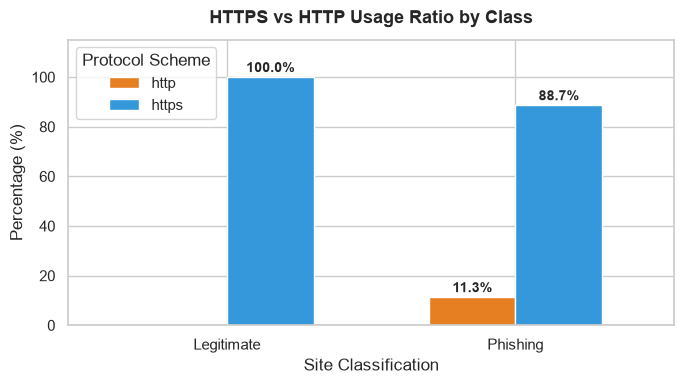

📊 Protocol Distribution Breakdown (Percentage Matrix):
------------------------------------------------------------
protocol    http  https
class                  
Legitimate   0.0  100.0
Phishing    11.3   88.7


In [6]:
#HTTPS usage
# Guard check to verify df is loaded in memory
if 'df' in locals() or 'df' in globals():
    # 1. Isolate the network scheme (prefix)
    df['protocol'] = df['url'].str.extract(r'^(https?)', expand=False).fillna('other')
    
    # 2. Pivot the counts into a normalized cross-tabulation table (Percentages)
    cross = pd.crosstab(df['class'], df['protocol'], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    # FIX: Ensure color map safely aligns with columns ('http' and 'https')
    # If a category is missing, dictionary mapping prevents index color errors
    protocol_colors = {'https': '#3498db', 'http': '#e67e22', 'other': '#95a5a6'}
    active_colors = [protocol_colors[col] for col in cross.columns]
    
    # 3. Plot the stacked or grouped bar chart
    cross.plot(kind='bar', ax=ax, edgecolor='white', color=active_colors, width=0.6)
    
    ax.set_title('HTTPS vs HTTP Usage Ratio by Class', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Site Classification')
    ax.set_xticklabels(cross.index, rotation=0)
    ax.set_ylim(0, 115)  # Make space for a clean legend placement
    
    # Polish the chart legend display
    ax.legend(title="Protocol Scheme", frameon=True, facecolor='white')
    
    # Add values on top of the bars for scannability
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Skip drawing text for zero elements
            ax.text(p.get_x() + p.get_width() / 2, height + 2,
                    f"{height:.1f}%", ha='center', fontsize=10, fontweight='bold')
            
    plt.tight_layout()
    
    # REAL FIX: Use your predefined REPORTS_DIR path object
    save_path = REPORTS_DIR / 'eda_https_usage.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    # 4. Print explicit cross-tab statistics table right below
    print("📊 Protocol Distribution Breakdown (Percentage Matrix):")
    print("-" * 60)
    print(cross.round(1).to_string())
else:
    print("❌ Error: 'df' is not defined. Please run Cell 1 first.")

In [7]:
#Write EDA findings
# Guard check to verify df and engineered attributes are loaded in memory
if 'df' in locals() or 'df' in globals():
    # Fail-safe calculation in case cells were run out of order
    if 'url_length' not in df.columns:
        df['url_length'] = df['url'].str.len()
    if 'protocol' not in df.columns:
        df['protocol'] = df['url'].str.extract(r'^(https?)', expand=False).fillna('other')

    print("=" * 55)
    print("                EDA KEY FINDINGS SUMMARY")
    print("=" * 55)
    
    # 1. Dataset Balance Metrics
    total_urls = len(df)
    phish_count = df['label'].sum()
    legit_count = (df['label'] == 0).sum()
    
    print(f"Total Combined URLs       : {total_urls:,}")
    print(f"  🔹 Phishing Records     : {phish_count:,} ({phish_count / total_urls * 100:.1f}%)")
    print(f"  🔹 Legitimate Records   : {legit_count:,} ({legit_count / total_urls * 100:.1f}%)")
    print("-" * 55)
    
    # 2. Length Features Metrics
    phish_len_avg = df[df['label'] == 1]['url_length'].mean()
    legit_len_avg = df[df['label'] == 0]['url_length'].mean()
    print(f"Avg URL Length (Phishing)   : {phish_len_avg:.1f} characters")
    print(f"Avg URL Length (Legitimate) : {legit_len_avg:.1f} characters")
    print("-" * 55)
    
    # 3. Security Protocol Features Metrics
    pct_https_phish = (df[df['label'] == 1]['protocol'] == 'https').mean() * 100
    pct_https_legit = (df[df['label'] == 0]['protocol'] == 'https').mean() * 100
    print(f"HTTPS Usage (Phishing)      : {pct_https_phish:.1f}%")
    print(f"HTTPS Usage (Legitimate)    : {pct_https_legit:.1f}%")
    print("=" * 55)
    
    # 4. Save metrics to a text report file automatically
    metrics_path = REPORTS_DIR / 'eda_summary_metrics.txt'
    with open(metrics_path, 'w', encoding='utf-8') as f:
        f.write("=" * 55 + "\n")
        f.write("                EDA KEY FINDINGS SUMMARY\n")
        f.write("=" * 55 + "\n")
        f.write(f"Total Combined URLs       : {total_urls:,}\n")
        f.write(f"  🔹 Phishing Records     : {phish_count:,} ({phish_count / total_urls * 100:.1f}%)\n")
        f.write(f"  🔹 Legitimate Records   : {legit_count:,} ({legit_count / total_urls * 100:.1f}%)\n")
        f.write("-" * 55 + "\n")
        f.write(f"Avg URL Length (Phishing)   : {phish_len_avg:.1f} characters\n")
        f.write(f"Avg URL Length (Legitimate) : {legit_len_avg:.1f} characters\n")
        f.write("-" * 55 + "\n")
        f.write(f"HTTPS Usage (Phishing)      : {pct_https_phish:.1f}%\n")
        f.write(f"HTTPS Usage (Legitimate)    : {pct_https_legit:.1f}%\n")
        f.write("=" * 55 + "\n")
        
    print(f"📝 Findings log cleanly written to: {metrics_path}")
else:
    print("❌ Error: 'df' is not defined. Please run Cell 1 first.")

                EDA KEY FINDINGS SUMMARY
Total Combined URLs       : 40,000
  🔹 Phishing Records     : 20,000 (50.0%)
  🔹 Legitimate Records   : 20,000 (50.0%)
-------------------------------------------------------
Avg URL Length (Phishing)   : 49.4 characters
Avg URL Length (Legitimate) : 21.8 characters
-------------------------------------------------------
HTTPS Usage (Phishing)      : 88.7%
HTTPS Usage (Legitimate)    : 100.0%
📝 Findings log cleanly written to: C:\phishing\phishing-detection-system\Reports\eda_summary_metrics.txt
